In [1]:
from sklearn.datasets import load_digits
import pandas as pd

# Load the digits dataset from scikit-learn
digits = load_digits()

# Create a DataFrame for the pixel features and keep the original digit label
data = pd.DataFrame(digits.data, columns=[f"pixel_{i}" for i in range(digits.data.shape[1])])
data["digit"] = digits.target

data.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,digit
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [2]:
# Class distribution of the digit labels
data["digit"].value_counts().sort_index()

digit
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

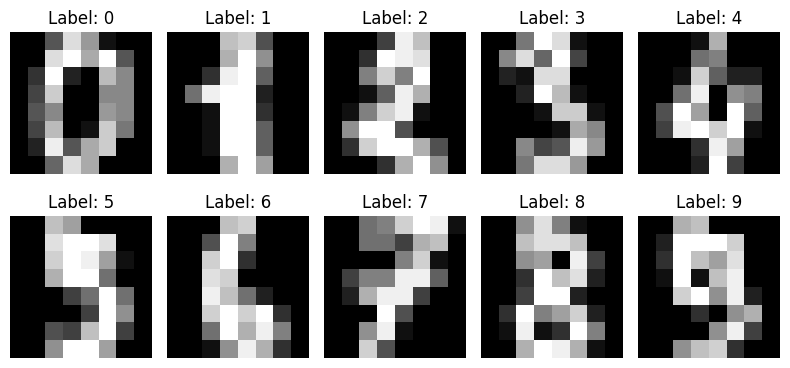

In [3]:
import matplotlib.pyplot as plt

# Visualize a few example digits
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")

plt.tight_layout()

In [4]:
# Basic shape of the dataset
print("Data shape (rows, cols):", data.shape)
print("Unique digit labels:", sorted(data["digit"].unique()))

Data shape (rows, cols): (1797, 65)
Unique digit labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [5]:
data.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,digit
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


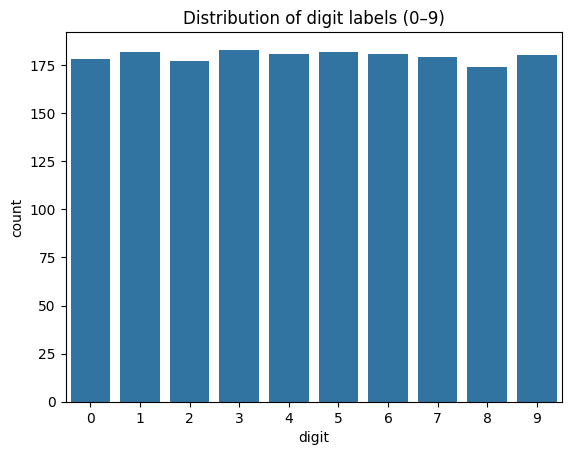

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of digit labels
sns.countplot(x=data["digit"])
plt.title("Distribution of digit labels (0–9)")
plt.show()

In [7]:
# Create a binary target: 1 if digit >= 5, else 0
high_quality = (data["digit"] >= 5).astype(int)
data["quality"] = high_quality

data[["digit", "quality"]].head()

,digit,quality
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


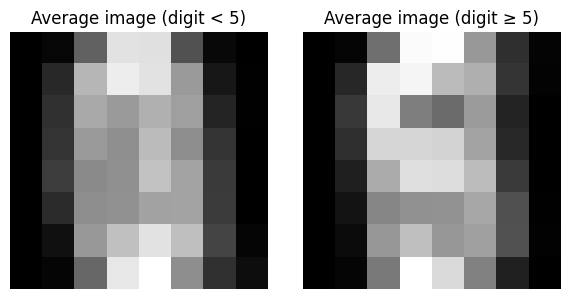

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize the average image for low vs high digits
avg_image_low = digits.images[high_quality == 0].mean(axis=0)
avg_image_high = digits.images[high_quality == 1].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(avg_image_low, cmap="gray")
axes[0].set_title("Average image (digit < 5)")
axes[0].axis("off")

axes[1].imshow(avg_image_high, cmap="gray")
axes[1].set_title("Average image (digit ≥ 5)")
axes[1].axis("off")

plt.tight_layout()

In [9]:
data.isna().any()


pixel_0     False
pixel_1     False
pixel_2     False
pixel_3     False
pixel_4     False
            ...  
pixel_61    False
pixel_62    False
pixel_63    False
digit       False
quality     False
Length: 66, dtype: bool

In [10]:
from sklearn.model_selection import train_test_split

# Use pixel features as X and the binary "quality" label as y
X = data.drop(["quality", "digit"], axis=1)
y = data["quality"]

# Split out the training data
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123)

# Split the remaining data equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123)

In [11]:
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env
import cloudpickle
import time

class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
  def __init__(self, model):
    self.model = model

  def predict(self, context, model_input):
    return self.model.predict_proba(model_input)[:, 1]

with mlflow.start_run(run_name="logreg_digits_baseline"):
    C = 1.0
    model = LogisticRegression(max_iter=1000, C=C, solver="lbfgs")
    model.fit(X_train, y_train)

    predictions_test = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, predictions_test)
    mlflow.log_param("C", C)
    mlflow.log_metric("auc", auc_score)
    wrappedModel = SklearnModelWrapper(model)
    signature = infer_signature(X_train, wrappedModel.predict(None, X_train))

    conda_env = _mlflow_conda_env(
            additional_conda_deps=None,
            additional_pip_deps=[
                "cloudpickle=={}".format(cloudpickle.__version__),
                "scikit-learn=={}".format(sklearn.__version__),
            ],
            additional_conda_channels=None,
        )
    mlflow.pyfunc.log_model(
        name="logreg_digits_model",
        python_model=wrappedModel,
        conda_env=conda_env,
        signature=signature,
    )

/opt/miniconda3/envs/mlflow-lab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/mlflow-lab/lib/python3.10/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/03/26 20:45:34 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ fo

In [12]:
# Inspect feature importances via absolute logistic regression coefficients
import numpy as np

coefs = np.abs(model.coef_).ravel()
feature_importances = pd.DataFrame(coefs, index=X_train.columns.tolist(), columns=["importance"])
feature_importances.sort_values("importance", ascending=False).head(10)

,importance
pixel_8,1.030653
pixel_16,0.989659
pixel_23,0.888437
pixel_24,0.875001
pixel_57,0.692361
pixel_31,0.533416
pixel_63,0.494962
pixel_15,0.438088
pixel_33,0.357368
pixel_52,0.352114


In [13]:
# Get the run_id of the baseline logistic regression model we just trained
baseline_run = mlflow.search_runs(
    filter_string='tags.mlflow.runName = "logreg_digits_baseline"'
).iloc[0]
run_id = baseline_run.run_id

In [14]:
# If you see the error "PERMISSION_DENIED: User does not have any permission level assigned to the registered model", 
# the cause may be that a model already exists with the name "digit_classifier". Try using a different name.
model_name = "digit_classifier"
model_version = mlflow.register_model(f"runs:/{run_id}/logreg_digits_model", model_name)
 
# Registering the model takes a few seconds, so add a small delay
time.sleep(15)

Registered model 'digit_classifier' already exists. Creating a new version of this model...
2026/03/26 20:45:35 WARNING mlflow.tracking._model_registry.fluent: Run with id a4a5073a1e694d7bb104f5d38a2c92ba has no artifacts at artifact path 'logreg_digits_model', registering model based on models:/m-b315b40341e946d18694ceb1f3cae083 instead
Created version '9' of model 'digit_classifier'.


In [15]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

client.transition_model_version_stage(
  name=model_name,
  version=model_version.version,
  stage="Production",
)

/var/folders/tt/5p4n3c3n5psgy9jz0xcy1z680000gn/T/ipykernel_33182/393290084.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1774572335195, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1774572350231, metrics=None, model_id=None, name='digit_classifier', params=None, run_id='a4a5073a1e694d7bb104f5d38a2c92ba', run_link=None, source='models:/m-b315b40341e946d18694ceb1f3cae083', status='READY', status_message=None, tags={}, user_id=None, version=9, workspace='default'>

In [16]:
model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")
 
# Sanity-check: This should match the AUC logged by MLflow
auc_loaded = roc_auc_score(y_test, model.predict(X_test))
print(f"AUC: {auc_loaded}")

AUC: 0.9483666033446483


In [17]:
from hyperopt import fmin, tpe, hp, SparkTrials, Trials, STATUS_OK  
from hyperopt.pyll import scope  
from math import exp  
import mlflow.xgboost  
import numpy as np  
import xgboost as xgb  

search_space = {
  'max_depth': scope.int(hp.quniform('max_depth', 4, 20, 1)),
  'learning_rate': hp.loguniform('learning_rate', -3, 0),
  'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
  'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
  'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
  'objective': 'binary:logistic',
  'seed': 123,
}

/opt/miniconda3/envs/mlflow-lab/lib/python3.10/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [18]:
def train_model(params):
      # With MLflow autologging, hyperparameters and the trained model are automatically logged to MLflow.
    mlflow.xgboost.autolog()
    with mlflow.start_run(nested=True):
        train = xgb.DMatrix(data=X_train, label=y_train)
        validation = xgb.DMatrix(data=X_val, label=y_val)
        # Early stopping after 20 rounds (down from 50) for faster training
        booster = xgb.train(params=params, dtrain=train, num_boost_round=500,\
                            evals=[(validation, "validation")], early_stopping_rounds=20)
        validation_predictions = booster.predict(validation)
        auc_score = roc_auc_score(y_val, validation_predictions)
        mlflow.log_metric('auc', auc_score)

        signature = infer_signature(X_train, booster.predict(train))
        mlflow.xgboost.log_model(name="model", xgb_model=booster, signature=signature)

        # Set the loss to -1*auc_score so fmin maximizes the auc_score
        return {'status': STATUS_OK, 'loss': -1*auc_score, 'booster': booster.attributes()}

In [19]:
import pyspark  
from pyspark import SparkContext, SparkConf  

conf_spark = SparkConf().set("spark.driver.host", "127.0.0.1")
sc = SparkContext(conf=conf_spark)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/26 20:45:51 WARN Utils: Your hostname, Sahils-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.174 instead (on interface en0)
26/03/26 20:45:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/26 20:45:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [20]:
spark_trials = SparkTrials(parallelism=4)

with mlflow.start_run(run_name='xgboost_models'):
  best_params = fmin(
    fn=train_model, 
    space=search_space, 
    algo=tpe.suggest,
    max_evals=12,
    trials=spark_trials,
  )

  0%|        | 0/12 [00:00<?, ?trial/s, best loss=?]

26/03/26 20:45:53 WARN FileSystem: Cannot load filesystem
java.util.ServiceConfigurationError: org.apache.hadoop.fs.FileSystem: Provider org.apache.hadoop.fs.viewfs.ViewFileSystem could not be instantiated
	at java.base/java.util.ServiceLoader.fail(ServiceLoader.java:582)
	at java.base/java.util.ServiceLoader$ProviderImpl.newInstance(ServiceLoader.java:809)
	at java.base/java.util.ServiceLoader$ProviderImpl.get(ServiceLoader.java:725)
	at java.base/java.util.ServiceLoader$3.next(ServiceLoader.java:1397)
	at org.apache.hadoop.fs.FileSystem.loadFileSystems(FileSystem.java:3525)
	at org.apache.hadoop.fs.FileSystem.getFileSystemClass(FileSystem.java:3562)
	at org.apache.hadoop.fs.FsUrlStreamHandlerFactory.<init>(FsUrlStreamHandlerFactory.java:77)
	at org.apache.spark.sql.internal.SharedState$.liftedTree2$1(SharedState.scala:209)
	at org.apache.spark.sql.internal.SharedState$.org$apache$spark$sql$internal$SharedState$$setFsUrlStreamHandlerFactory(SharedState.scala:208)
	at org.apache.spark.

 25%|▎| 3/12 [00:12<00:36,  4.01s/trial, best loss: 

/opt/miniconda3/envs/mlflow-lab/lib/python3.10/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026/03/26 20:46:07 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.1.0 <= xgboost, but the installed version is 1.7.6. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.
                                                                                

 33%|▎| 4/12 [00:14<00:26,  3.37s/trial, best loss: 

...

[0]	validation-logloss:0.62968
[1]	validation-logloss:0.58067
[2]	validation-logloss:0.54199
[3]	validation-logloss:0.51014
[4]	validation-logloss:0.48739
[5]	validation-logloss:0.46146
[6]	validation-logloss:0.43001
[7]	validation-logloss:0.40631
[8]	validation-logloss:0.38867
[9]	validation-logloss:0.37114
[10]	validation-logloss:0.35886
[11]	validation-logloss:0.33860
[12]	validation-logloss:0.32135
[13]	validation-logloss:0.31282
[14]	validation-logloss:0.30423
[15]	validation-logloss:0.29026
[16]	validation-logloss:0.27961
[17]	validation-logloss:0.27245
[18]	validation-logloss:0.26357
[19]	validation-logloss:0.25682
[20]	validation-logloss:0.24969
[21]	validation-logloss:0.24438
[22]	validation-logloss:0.23994
[23]	validation-logloss:0.23811
[24]	validation-logloss:0.23491
[25]	validation-logloss:0.23144
[26]	validation-logloss:0.22901
[27]	validation-logloss:0.22581
[28]	validation-logloss:0.22245
[29]	validation-logloss:0.22055
[30]	validation-logloss:0.21991
[31]	validation-lo

 75%|▊| 9/12 [00:31<00:10,  3.65s/trial, best loss: 

 83%|▊| 10/12 [00:32<00:05,  2.85s/trial, best loss:

100%|█| 12/12 [00:33<00:00,  2.76s/trial, best loss:


Total Trials: 12: 12 succeeded, 0 failed, 0 cancelled.


In [21]:
best_run = mlflow.search_runs(order_by=['metrics.auc DESC']).iloc[0]
print(f'AUC of Best Run: {best_run["metrics.auc"]}')

AUC of Best Run: 0.9985664422837197


In [22]:
new_model_version = mlflow.register_model(f"runs:/{best_run.run_id}/model", model_name)
 
# Registering the model takes a few seconds, so add a small delay
time.sleep(10)

Registered model 'digit_classifier' already exists. Creating a new version of this model...
2026/03/26 20:46:28 WARNING mlflow.tracking._model_registry.fluent: Run with id aa477a146572400bbf424e9c2db033a0 has no artifacts at artifact path 'model', registering model based on models:/m-f0a8222360984e498adf8d9c8bc309cc instead
Created version '10' of model 'digit_classifier'.


In [23]:
client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage='Archived'
)

client.transition_model_version_stage(
    name=model_name,
    version=new_model_version.version,
    stage='Production'
)

/var/folders/tt/5p4n3c3n5psgy9jz0xcy1z680000gn/T/ipykernel_33182/517306411.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
/var/folders/tt/5p4n3c3n5psgy9jz0xcy1z680000gn/T/ipykernel_33182/517306411.py:7: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1774572388231, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1774572398272, metrics=None, model_id=None, name='digit_classifier', params=None, run_id='aa477a146572400bbf424e9c2db033a0', run_link=None, source='models:/m-f0a8222360984e498adf8d9c8bc309cc', status='READY', status_message=None, tags={}, user_id=None, version=10, workspace='default'>

In [24]:
model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")
print(f"AUC: {roc_auc_score(y_test, model.predict(X_test))}")

AUC: 0.9937093207934975


In [25]:
import mlflow.pyfunc

from pyspark.sql import SparkSession

# Create or retrieve a Spark session
spark = SparkSession.builder \
    .appName("MLflow Integration") \
    .config("spark.some.config.option", "config-value") \
    .getOrCreate()

apply_model_udf = mlflow.pyfunc.spark_udf(spark, f"models:/{model_name}/production")

26/03/26 20:46:38 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
2026/03/26 20:46:38 WARNING mlflow.pyfunc: Calling `spark_udf()` with `env_manager="local"` does not recreate the same environment that was used during training, which may lead to errors or inaccurate predictions. We recommend specifying `env_manager="conda"`, which automatically recreates the environment that was used to train the model and performs inference in the recreated environment.
2026/03/26 20:46:38 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'


In [26]:
# Optional: Serve the model (requires separate terminal)
# mlflow models serve --env-manager=local -m models:/digit_classifier/production -h 0.0.0.0 -p 5001

In [27]:
# Optional: Test model serving via HTTP (requires server to be running)
# import requests
# import json
# 
# url = 'http://localhost:5001/invocations'
# datads_dict = {"dataframe_split": X_test.to_dict(orient='split')}
# response = requests.post(url, json=datads_dict)
# predictions = response.json()
# print(predictions)

In [28]:
# Validation: Check model outputs
print("=" * 60)
print("MODEL VALIDATION")
print("=" * 60)

# Load production model and check predictions
production_model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")
test_predictions = production_model.predict(X_test)

# Verify outputs are probabilities (between 0 and 1)
print(f"\n1. Prediction Range Check:")
print(f"   Min prediction: {test_predictions.min():.4f} (should be >= 0)")
print(f"   Max prediction: {test_predictions.max():.4f} (should be <= 1)")
assert test_predictions.min() >= 0 and test_predictions.max() <= 1, "Predictions out of valid probability range!"

# Verify AUC on test set
auc_final = roc_auc_score(y_test, test_predictions)
print(f"\n2. AUC Score: {auc_final:.4f} (should be > 0.5)")
assert auc_final > 0.5, "AUC too low!"

# Sample predictions
print(f"\n3. Sample Predictions (first 10 test samples):")
print(f"   Actual:     {y_test.iloc[:10].values}")
print(f"   Predicted:  {test_predictions[:10].round(4)}")

# Threshold analysis
threshold = 0.5
binary_preds = (test_predictions > threshold).astype(int)
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, binary_preds)
print(f"\n4. Confusion Matrix (threshold={threshold}):")
print(f"   TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"   FN: {cm[1,0]}, TP: {cm[1,1]}")

print(f"\n5. Classification Report:")
print(classification_report(y_test, binary_preds))

print("\n✓ Model validation passed!")
print("=" * 60)

MODEL VALIDATION

1. Prediction Range Check:
   Min prediction: 0.0000 (should be >= 0)
   Max prediction: 1.0000 (should be <= 1)

2. AUC Score: 0.9937 (should be > 0.5)

3. Sample Predictions (first 10 test samples):
   Actual:     [0 0 0 1 1 1 0 0 0 1]
   Predicted:  [1.200e-03 7.000e-04 7.000e-04 9.992e-01 9.996e-01 9.995e-01 3.340e-02
 1.000e-04 2.700e-03 9.930e-01]

4. Confusion Matrix (threshold=0.5):
   TN: 190, FP: 7
   FN: 5, TP: 158

5. Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       197
           1       0.96      0.97      0.96       163

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360


✓ Model validation passed!


In [29]:
# Launch MLflow UI to view experiments, metrics, and models
import subprocess
import time

print("Starting MLflow UI on port 5000...")
print("Open your browser to: http://localhost:5000")
print("\nPress CTRL+C in the terminal to stop the server.\n")

subprocess.Popen(["mlflow", "ui", "--port", "5000"])
time.sleep(2)
print("MLflow UI started!")

Starting MLflow UI on port 5000...
Open your browser to: http://localhost:5000

Press CTRL+C in the terminal to stop the server.

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.


[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
INFO:     Started parent process [33494]


MLflow UI started!


2026/03/26 20:46:40 INFO mlflow.server.jobs.utils: Starting huey consumer for job function invoke_scorer
2026/03/26 20:46:40 INFO mlflow.server.jobs.utils: Starting huey consumer for job function optimize_prompts
2026/03/26 20:46:40 INFO mlflow.server.jobs.utils: Starting huey consumer for job function run_online_session_scorer
2026/03/26 20:46:40 INFO mlflow.server.jobs.utils: Starting huey consumer for job function run_online_trace_scorer
2026/03/26 20:46:40 INFO mlflow.server.jobs.utils: Starting dedicated Huey consumer for periodic tasks
INFO:     Started server process [33500]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started server process [33499]
INFO:     Waiting for application startup.
INFO:     Started server process [33498]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Application startup complete.
INFO:     Started server process [33497]
INFO:     Waiting for application start